# Lattice Surgery Tutorial

This notebook provides a quick introduction to using the lattice surgery algorithms implemented in this repository.

### Step 1: Compile the C++ program

First, we need to compile the main program using g++.

In [1]:
%%bash
g++ -O3 -march=native -mtune=native -std=c++17 -Wall -Wextra -o src/cpp/main.out src/cpp/main.cpp
echo "Compilation successful!"

Compilation successful!


### Step 2: Try an example circuits


In [2]:
import os
import subprocess
from pathlib import Path

circuit_path = "data/example/demo.in"
assert os.path.exists(circuit_path), f"Circuit file not found: {circuit_path}"

result = subprocess.run(
    ["./main.out", f"../../{circuit_path}"],
    capture_output=True,
    text=True,
    cwd="src/cpp",
)
print(result.stdout)

output_line = result.stdout.strip().split("\n")[-1]
if not output_line.startswith("Output path"):
    raise ValueError("Unexpected output format")
output_path = Path("src/cpp") / output_line.split(":", 1)[1].strip()
if not output_path.exists():
    raise FileNotFoundError(f"Output file not found: {output_path}")

Best schedule result: 16
Output path: ../../out/result/demo_outer_SA_2_1000000_CareKinkParity.out



### Step 3: Visualize the result

Now let's visualize the output using the `out2png.py` tool to generate an SVG visualization.


Displaying first 3 time steps:

--- Time step 000 ---


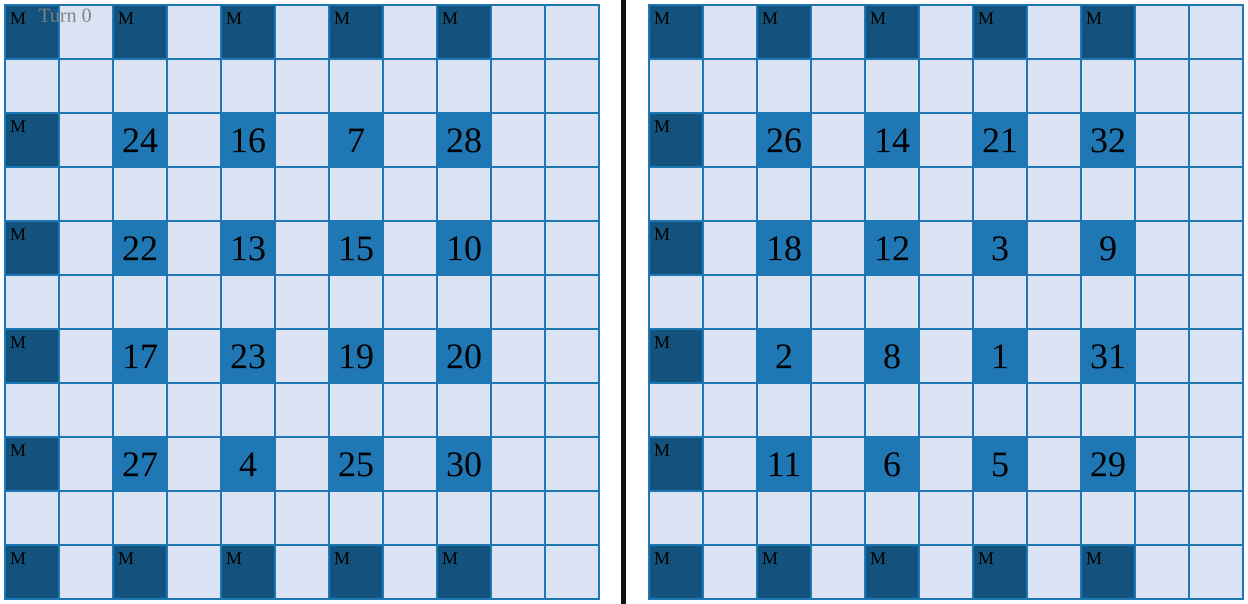


--- Time step 001 ---


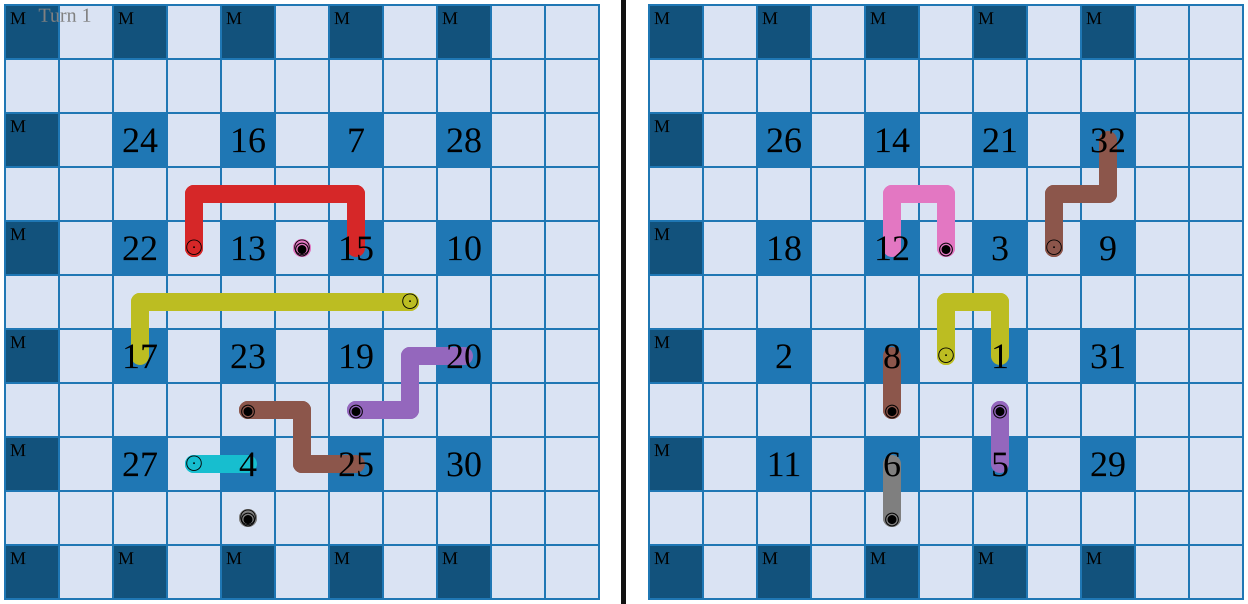


--- Time step 002 ---


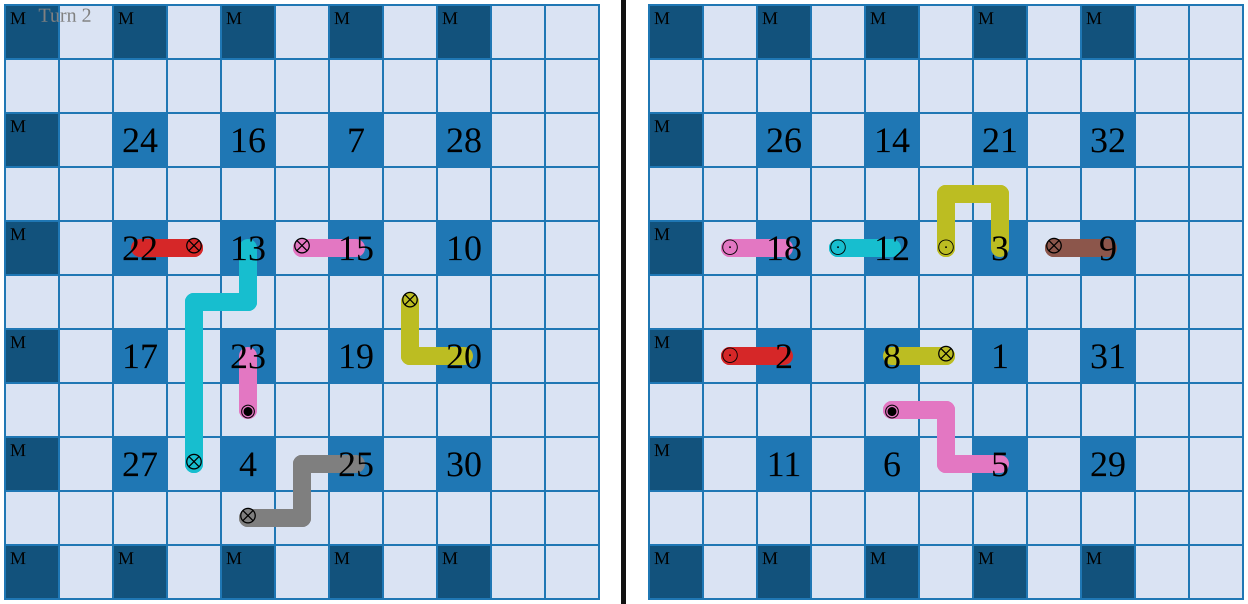

In [3]:
from IPython.display import SVG, display
import json

# Run out2png.py to generate SVG visualization
result = subprocess.run(
    ["python", "other/out2png/_simple_ver_for_tutorial.py", str(output_path)],
    capture_output=True,
    text=True,
)

svg_dict = json.loads(result.stdout)

# Display first few time steps
print("\nDisplaying first 3 time steps:")
for i, (turn, svg_content) in enumerate(list(svg_dict.items())[:3]):
    print(f"\n--- Time step {turn} ---")
    display(SVG(svg_content))

### Step 4: Create your own custom circuit

You can also create your own custom circuit by defining the gates as a string. The format supports:
- `CX control_qubit target_qubit` - CNOT gate
- `MAGIC_MOVE qubit` - Magic state move operation
- `MAGIC_MZZ qubit` - Magic ZZ measurement

Let's create a simple custom circuit:

In [4]:
# Define a custom circuit as a string
# This example creates a simple circuit with CNOT gates forming a chain pattern
custom_circuit = """CX 0 1
CX 1 2
CX 2 3
CX 3 4
MAGIC_MOVE 2
CX 4 2
CX 3 1
CX 2 0
"""

# Save it to a temporary file
custom_circuit_path = Path("data/example/custom_tutorial.in")
custom_circuit_path.write_text(custom_circuit)
print(f"Custom circuit saved to: {custom_circuit_path}")
print(f"\nCircuit content:\n{custom_circuit}")

Custom circuit saved to: data/example/custom_tutorial.in

Circuit content:
CX 0 1
CX 1 2
CX 2 3
CX 3 4
MAGIC_MOVE 2
CX 4 2
CX 3 1
CX 2 0



Now let's run the lattice surgery algorithm on this custom circuit:

In [5]:
# Run the main program on our custom circuit
result = subprocess.run(
    ["./main.out", f"../../{str(custom_circuit_path)}"],
    capture_output=True,
    text=True,
    cwd="src/cpp",
)
print(result.stdout)

# Extract output path
output_line = result.stdout.strip().split("\n")[-1]
if not output_line.startswith("Output path"):
    raise ValueError("Unexpected output format")
custom_output_path = Path("src/cpp") / output_line.split(":", 1)[1].strip()
if not custom_output_path.exists():
    raise FileNotFoundError(f"Output file not found: {custom_output_path}")
print(f"Output successfully generated at: {custom_output_path}")

Best schedule result: 5
Output path: ../../out/result/custom_tutorial_outer_SA_2_1000000_CareKinkParity.out

Output successfully generated at: src/cpp/../../out/result/custom_tutorial_outer_SA_2_1000000_CareKinkParity.out


Visualize the custom circuit result:

Displaying first 5 time steps of custom circuit:

--- Time step 000 ---


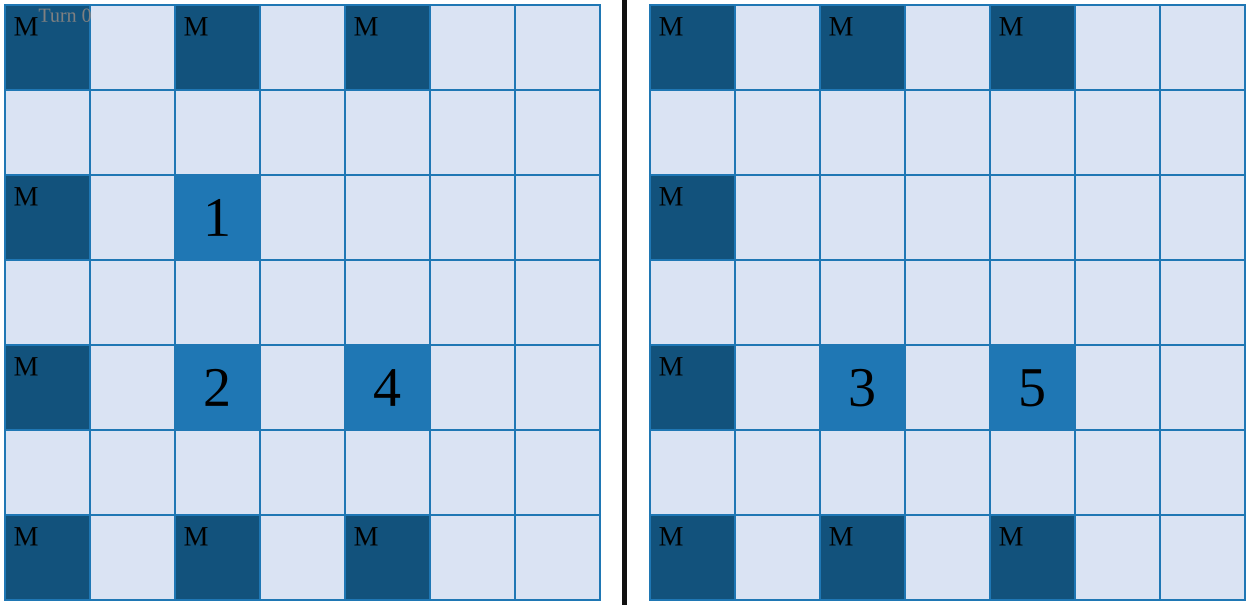


--- Time step 001 ---


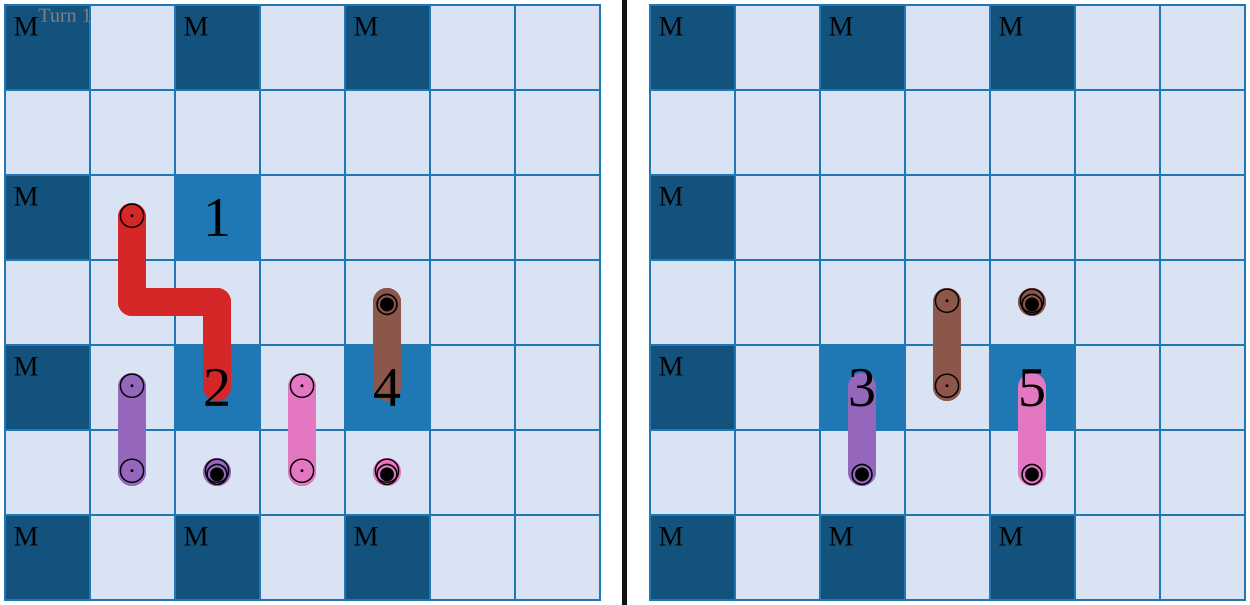


--- Time step 002 ---


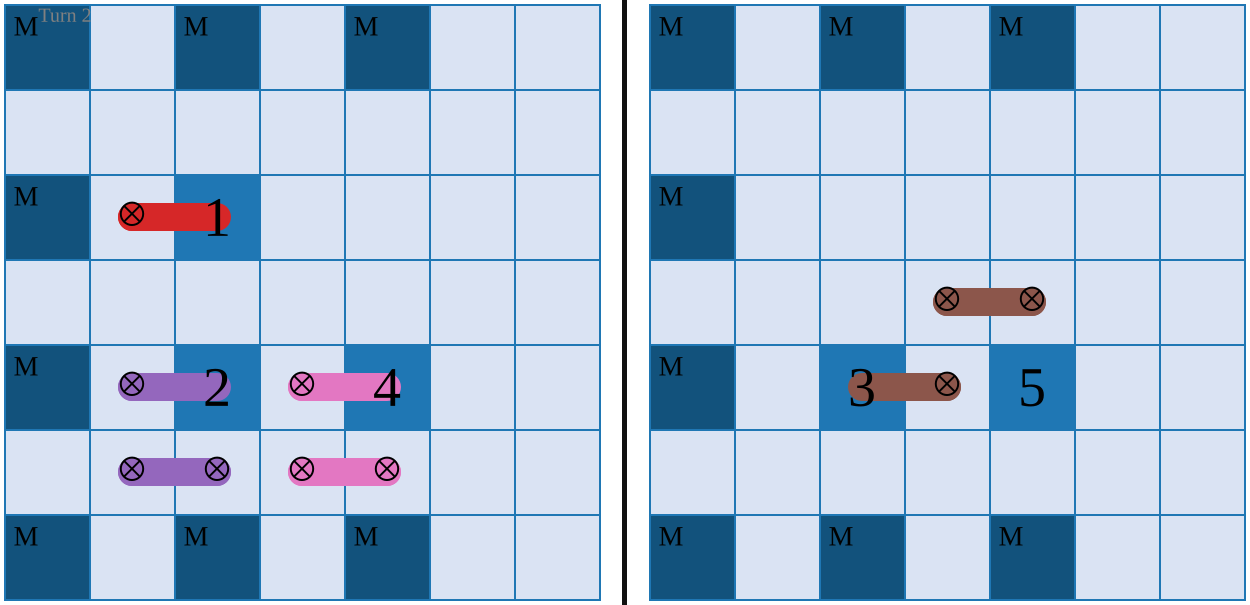


--- Time step 003 ---


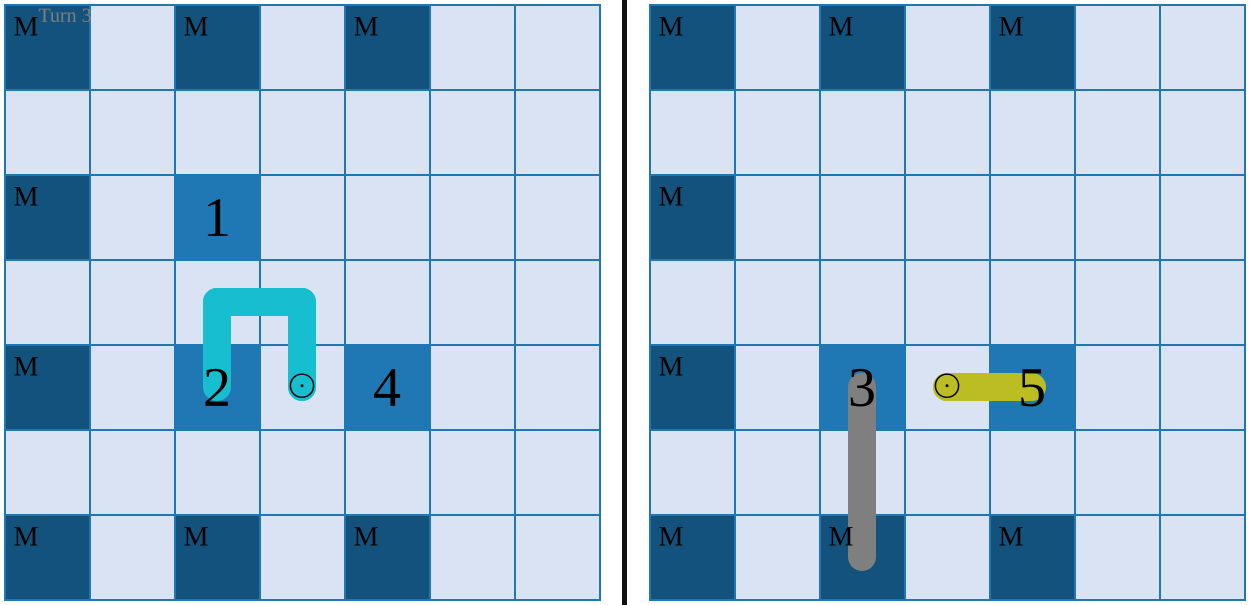


--- Time step 004 ---


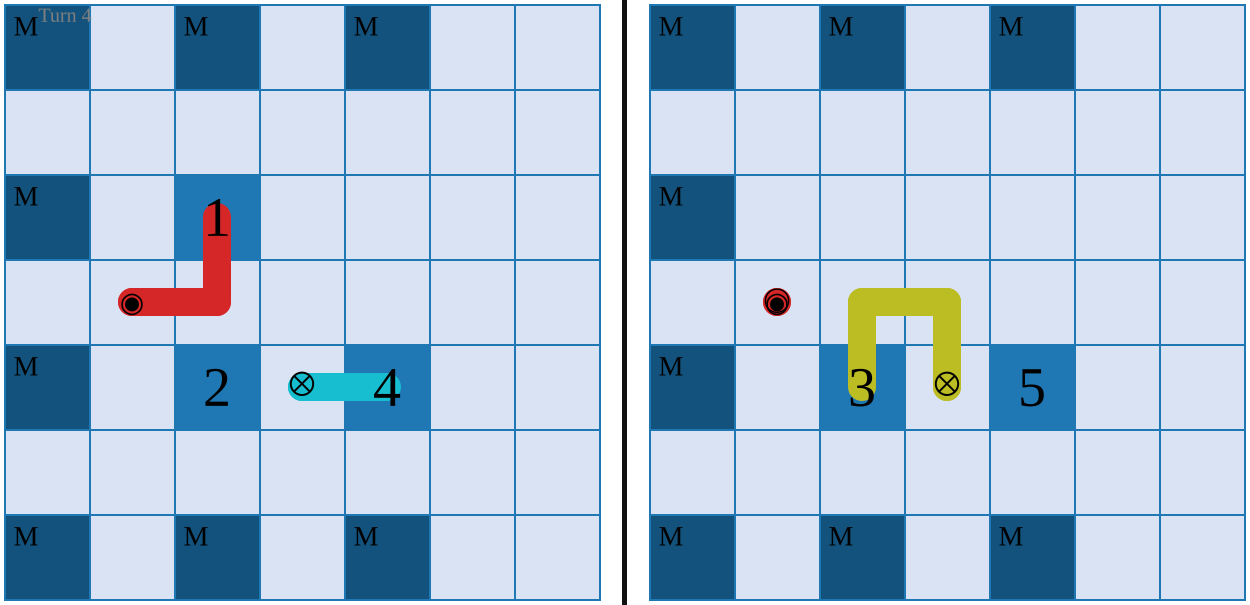

In [6]:
# Generate and display SVG visualization for the custom circuit
result = subprocess.run(
    [
        "python",
        "other/out2png/_simple_ver_for_tutorial.py",
        str(custom_output_path),
    ],
    capture_output=True,
    text=True,
)

custom_svg_dict = json.loads(result.stdout)

# Display first few time steps of the custom circuit
print("Displaying first 5 time steps of custom circuit:")
for i, (turn, svg_content) in enumerate(list(custom_svg_dict.items())[:5]):
    print(f"\n--- Time step {turn} ---")
    display(SVG(svg_content))